In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
os.getcwd()

'/Users/carriezhang/Documents/Coding/Trading Backtest/Loan_Default'

# Data Preprocessing

In [25]:
df = pd.read_csv('Loan_Default.csv')
print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')


In [26]:
# Check missing values
print(df.isnull().sum())
print(f"Missing percentage:\n{(df.isnull().sum() / len(df) * 100).round(2)}%")

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [27]:
# Analyze missing data patterns
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data)


                           Missing_Count  Missing_Percentage Data_Type
Upfront_charges                    39642             26.6600   float64
Interest_rate_spread               36639             24.6400   float64
rate_of_interest                   36439             24.5100   float64
dtir1                              24121             16.2200   float64
property_value                     15098             10.1600   float64
LTV                                15098             10.1600   float64
income                              9150              6.1500   float64
loan_limit                          3344              2.2500       str
approv_in_adv                        908              0.6100       str
age                                  200              0.1300       str
submission_of_application            200              0.1300       str
loan_purpose                         134              0.0900       str
Neg_ammortization                    121              0.0800       str
term  

In [13]:
from scipy.stats import chi2_contingency

overall_default = df['Status'].mean()
print(f"Overall default rate: {overall_default:.2%}  (n={len(df):,})\n")

rows = []
for col in df.columns:
    n_missing = df[col].isnull().sum()
    if n_missing == 0 or col == 'Status':
        continue
    flag = df[col].isnull()
    dr_missing  = df.loc[flag,  'Status'].mean()   # default rate when col IS missing
    dr_present  = df.loc[~flag, 'Status'].mean()   # default rate when col is present
    # chi-square test of independence: missing-flag vs default
    ct = pd.crosstab(flag, df['Status'])
    chi2, p, _, _ = chi2_contingency(ct)
    rows.append({
        'column': col,
        'pct_missing': n_missing / len(df) * 100,
        'default_if_missing': dr_missing,
        'default_if_present': dr_present,
        'lift_vs_overall': dr_missing - overall_default,
        'p_value': p,
    })

signal = (pd.DataFrame(rows)
          .sort_values('lift_vs_overall', key=abs, ascending=False)
          .reset_index(drop=True))

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(signal.to_string(index=False))
print("\nNote: small p-value => missingness is NOT random w.r.t. default (informative).")


Overall default rate: 24.64%  (n=148,670)

                   column  pct_missing  default_if_missing  default_if_present  lift_vs_overall  p_value
         rate_of_interest      24.5100              1.0000              0.0018           0.7536   0.0000
     Interest_rate_spread      24.6445              1.0000              0.0000           0.7536   0.0000
                      age       0.1345              1.0000              0.2454           0.7536   0.0000
submission_of_application       0.1345              1.0000              0.2454           0.7536   0.0000
           property_value      10.1554              0.9999              0.1613           0.7534   0.0000
                      LTV      10.1554              0.9999              0.1613           0.7534   0.0000
          Upfront_charges      26.6644              0.9204              0.0014           0.6739   0.0000
                    dtir1      16.2245              0.6762              0.1632           0.4297   0.0000
            

In [38]:
missing_signal_columns = signal[signal['p_value'] < 0.01]['column'].tolist()
## LTV = loan_amount / property_value * 100 
## So the missing LTV values are the same as the missing property_value
missing_signal_columns.remove('LTV')  # remove() modifies in-place, returns None
print(f"Columns with significant missingness signal: {missing_signal_columns}")


Columns with significant missingness signal: ['rate_of_interest', 'Interest_rate_spread', 'age', 'submission_of_application', 'property_value', 'Upfront_charges', 'dtir1', 'income']


In [ ]:
# ============================================================
# CLEAN PREPROCESSING  ->  df_model
# Consolidates leakage removal + missing-data handling + safe feature engineering.
# Replaces the old df_clean pipeline, which leaked the label through missingness.
# (The chi-square / income / age cells above are diagnostics and stay as-is.)
# ============================================================

# ---- 1. Drop LEAKED columns -------------------------------------------------
# Blanked on (nearly) all defaulted rows during dataset construction, so their
# values/missingness encode the target. See the chi-square cell above.
leaked = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
          'property_value', 'LTV', 'dtir1']

# ---- 2. Drop identifiers (not predictive) -----------------------------------
ids = ['ID', 'year']

df_model = df.drop(columns=leaked + ids).copy()

# ---- 3. Drop the 200 leaked rows (age/submission blanked -> all defaults) ----
df_model = df_model.dropna(subset=['age', 'submission_of_application']).reset_index(drop=True)

# ---- 4. Categorical missing -> 'Unknown' (constant fill, cannot leak) --------
cat_cols = df_model.select_dtypes(include='object').columns
df_model[cat_cols] = df_model[cat_cols].fillna('Unknown')

# ---- 5. The ONE informative missing flag: income ----------------------------
# Missing income -> LOWER default (13.5% vs 25.4%): a real lower-risk segment,
# NOT leakage. Keep the flag; impute the value.
df_model['income_missing'] = df_model['income'].isnull().astype(int)

# ---- 6. Numeric missing -> median -------------------------------------------
# Simple imputation is fine here given tiny missingness (income 6%, term 0.03%).
# For full rigor, move these two fills INTO the model Pipeline so the median is
# learned on the training fold only (avoids minor train/test contamination).
for col in ['income', 'term']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# ---- 7. Safe, leak-free engineered features ---------------------------------
df_model['loan_to_income']   = df_model['loan_amount'] / (df_model['income'] + 1)
df_model['credit_below_600'] = (df_model['Credit_Score'] < 600).astype(int)

# ---- sanity checks ----------------------------------------------------------
assert df_model.isnull().sum().sum() == 0, "still have missing values!"
assert not any(c in df_model.columns for c in leaked), "a leaked column survived!"
print(f"df_model shape: {df_model.shape}   (rows dropped: {len(df) - len(df_model)})")
print(f"Default rate preserved: {df_model['Status'].mean():.2%}  (raw was {df['Status'].mean():.2%})")
print("\nColumns:", list(df_model.columns))

      income_bucket     n  default_rate
   (-0.001, 2520.0] 14777        0.4393
   (2520.0, 3360.0] 13991        0.3019
   (3360.0, 4140.0] 14025        0.2719
   (4140.0, 4920.0] 13755        0.2526
   (4920.0, 5760.0] 14080        0.2272
   (5760.0, 6660.0] 13226        0.2198
   (6660.0, 7800.0] 14119        0.2077
   (7800.0, 9360.0] 13857        0.1977
  (9360.0, 12180.0] 13807        0.1968
(12180.0, 578580.0] 13883        0.2090
            MISSING  9150        0.1354


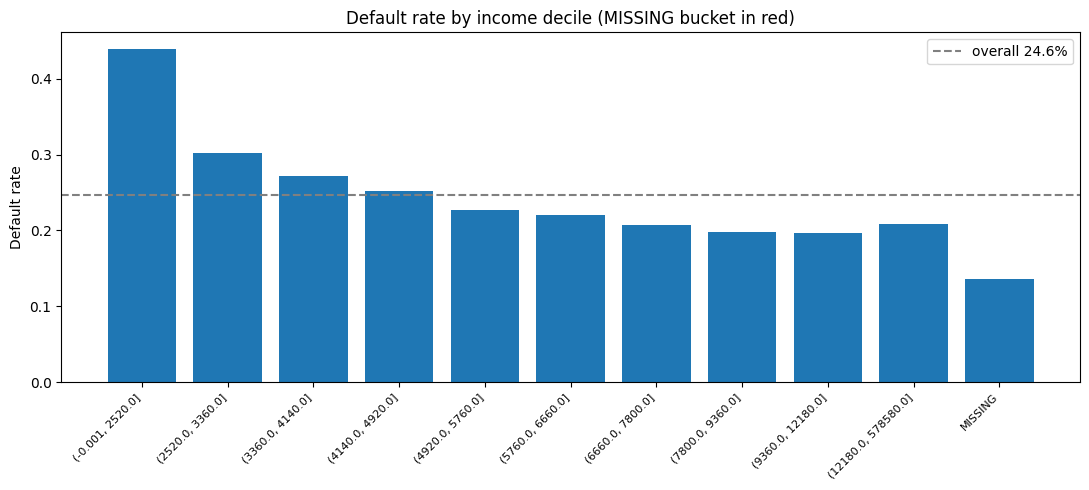


Missing-income default rate : 13.54%
Present-income default rate : 25.37%
=> Missing income behaves like a distinct, LOWER-risk segment, not the median.
   Recommended: add an `income_missing` flag column instead of (or alongside) median imputation.


In [ ]:
# ============================================================
# Focus on INCOME: where does the "missing income" group sit vs income deciles?
# ============================================================
inc = df[['income', 'Status']].copy()
inc['income_bucket'] = pd.qcut(inc['income'], 10, duplicates='drop').astype('str')
inc.loc[df['income'].isnull(), 'income_bucket'] = 'MISSING'

summary = (inc.groupby('income_bucket')['Status']
             .agg(n='count', default_rate='mean')
             .reset_index())
# put MISSING last, deciles in income order
summary['sort'] = summary['income_bucket'].apply(lambda x: 1e9 if x == 'MISSING' else float(x.split(',')[0].strip('([')))
summary = summary.sort_values('sort').drop(columns='sort').reset_index(drop=True)
print(summary.to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(11, 5))
#colors = ['b' if b != 'MISSING' else 'r' for b in summary['income_bucket']]
ax.bar(range(len(summary)), summary['default_rate'])
ax.axhline(df['Status'].mean(), color='gray', ls='--', label=f"overall {df['Status'].mean():.1%}")
ax.set_xticks(range(len(summary)))
ax.set_xticklabels(summary['income_bucket'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Default rate')
ax.set_title('Default rate by income decile (MISSING bucket in red)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMissing-income default rate : {df.loc[df['income'].isnull(),'Status'].mean():.2%}")
print(f"Present-income default rate : {df.loc[df['income'].notnull(),'Status'].mean():.2%}")
print("=> Missing income behaves like a distinct, LOWER-risk segment, not the median.")

In [ ]:
# ============================================================
# Income by AGE GROUP  (age is categorical bins, so we use a
# jittered "scatter": points spread horizontally within each group)
# ============================================================
order = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74']

d = df[['age', 'income']].dropna().copy()
d = d[d['age'].isin(order)]
d = d.sample(n=12000, random_state=42)   # 148k points is too dense to read

# map age bins -> x position, then add horizontal jitter
xpos = {a: i for i, a in enumerate(order)}
rng = np.random.default_rng(42)
d['x'] = d['age'].map(xpos) + rng.uniform(-0.32, 0.32, len(d))

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(d['x'], d['income'], s=6, alpha=0.25, color='steelblue', edgecolors='none')

# overlay median income per age group
med = df.groupby('age')['income'].median().reindex(order)
ax.plot(range(len(order)), med.values, 'o-', color='crimson', lw=2, ms=8, label='median income')

ax.set_ylim(0, 20000)   # income is right-skewed (max ~578k); clip for readability
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('Age group')
ax.set_ylabel('Income (monthly)')
ax.set_title('Income by age group (jittered scatter, n=12k sample; y clipped at 20k)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Median income by age group:')
print(med.round(0))

# Model

In [ ]:
from sklearn.model_selection import train_test_split

# Features / target
X = df_model.drop(columns='Status')
y = df_model['Status']

# Column types for preprocessing
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

# Stratified split — classes are imbalanced (~24.6% default), so preserve the ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print(f"Default rate — train: {y_train.mean():.2%},  test: {y_test.mean():.2%}")
print(f"\n{len(cat_cols)} categorical, {len(num_cols)} numeric features")
print("Categorical:", cat_cols)
print("Numeric    :", num_cols)

In [ ]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix)

def evaluate(model, name):
    """Evaluate a fitted classifier on the held-out test set.
    Uses AUC / PR-AUC (threshold-free) plus the classification report —
    NOT plain accuracy, which is misleading on imbalanced classes."""
    proba = model.predict_proba(X_test)[:, 1]
    pred  = model.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    print(f"=== {name} ===")
    print(f"ROC-AUC : {auc:.4f}")
    print(f"PR-AUC  : {ap:.4f}   (no-skill baseline = {y_test.mean():.3f})")
    print("\n" + classification_report(y_test, pred, digits=3))
    print("Confusion matrix [rows=true, cols=pred]:")
    print(confusion_matrix(y_test, pred))
    print()
    return auc

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocess: one-hot the categoricals, standardize the numerics.
# handle_unknown='ignore' -> categories unseen in training (e.g. a rare 'Unknown')
# won't crash at test time.
pre_linear = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])

logit = Pipeline([
    ('pre', pre_linear),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

logit.fit(X_train, y_train)
auc_logit = evaluate(logit, "Logistic Regression (baseline)")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Trees don't need scaling; just one-hot the categoricals and pass numerics through.
pre_tree = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols),
])

rf = Pipeline([
    ('pre', pre_tree),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,        # regularize: avoid memorizing single rows
        class_weight='balanced',    # handle the 75/25 imbalance
        n_jobs=-1,
        random_state=42)),
])

rf.fit(X_train, y_train)
auc_rf = evaluate(rf, "Random Forest")

In [ ]:
# Feature importances from the random forest + a leakage sanity check
ohe = rf.named_steps['pre'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = rf.named_steps['clf'].feature_importances_

imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# SANITY: no leaked column should appear anywhere in the feature set
leaked = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
          'property_value', 'LTV', 'dtir1']
assert not any(any(l in f for l in leaked) for f in feat_names), "leaked feature in model!"

print(f"Logistic AUC : {auc_logit:.4f}")
print(f"RandomForest AUC: {auc_rf:.4f}")
print("Sanity: no leaked columns in the feature set\n")

print("Top 20 features by importance:")
print(imp.head(20).round(4))

# plot
fig, ax = plt.subplots(figsize=(8, 6))
imp.head(20)[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Random Forest — top 20 feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()